In [1]:
import pandas as pd 
import numpy as np
import tensorflow as tf

import matplotlib.pyplot as plt

# 한글 패치 표준

plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# import urlib.request 

C:\Users\cyj\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
# 이미지 픽셀 값 : 0 ~ 255  => 0 ~ 1 범위로 변경 (정규화)
# BGR : OpenCV

img = plt.imread('./data/dog.jpg') / 255.0 # 0~1 범위로 정규화 
print("이미지 크기 : ",img.shape)   # (세로,가로,3채널)

이미지 크기 :  (1213, 1546, 3)


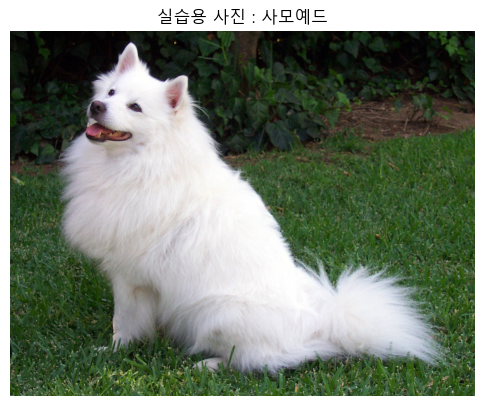

In [3]:
plt.figure(figsize = (6,6))
plt.imshow(img)
plt.axis('off')
plt.title("실습용 사진 : 사모예드")
plt.show()

### 1. Convolution(합성곱) - CNN의 눈 

- 작은 필터(3*3 숫자판)가 이미지를 훑으며 Feature 패턴(테두리 ,선)에 반응함
- CNN은 이런 필터를 수백개를 스스로 학습해서 물체를 탐지
- 

In [4]:
img.shape

(1213, 1546, 3)

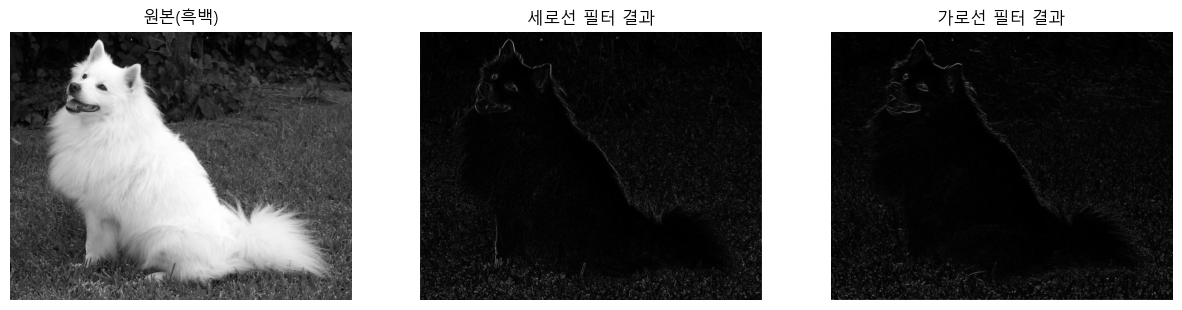

In [5]:
# plt.imread() 이미지를 읽을 경우 BGR이 아니라 RGB , cv2.imread()의 경우 BGR
# RGB 컬러 이미지를 흑백이미지로 변환
# np.newaxis : 이미지 1장이라는 배치 차원 추가 
# astype('float32') : Tensorflow는 실수형 계산에 유리함 - 딥러닝

gray = tf.image.rgb_to_grayscale(img[np.newaxis].astype('float32')) # 흑백+배치차원

# 세로선 필터 / 가로선 필터 (Sobel)
# 세로선 검출 sobel 필터
# 왼쪽과 오른쪽의 밝기 차이를 계싼해서 세로 경계선을 찾음 

# 3*3 크기의 필터 1개를 흑백 이미지에 적용 
k_세로 = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], np.float32).reshape(3,3,1,1) 
# reshape( 필터 세로 크기(높이) , 필터 가로 크기(너비) , 입력 채널 수(흑백 = 1) , 출력 채널 수(출력 필터 수 1)
k_가로 = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], np.float32).reshape(3,3,1,1)

# strdies=1 
# 필터를 이미지 위에서 한칸씩 옆으로 이동 
# padding = 'SAME'
# 출력 결과의 세로 , 가로 크기를 원본 이미지와 같게 유지
edge_v = tf.nn.conv2d(gray, k_세로, strides=1, padding='SAME')  # 합성곱 실행!
edge_h = tf.nn.conv2d(gray, k_가로, strides=1, padding='SAME')

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
plt.imshow(gray[0,:,:,0], cmap='gray') 
plt.title('원본(흑백)')
plt.axis('off')
plt.subplot(1,3,2) 
plt.imshow(abs(edge_v[0,:,:,0]), cmap='gray')
plt.title('세로선 필터 결과')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(abs(edge_h[0,:,:,0]), cmap='gray')
plt.title('가로선 필터 결과')
plt.axis('off')
plt.show()

### 2. Pooling

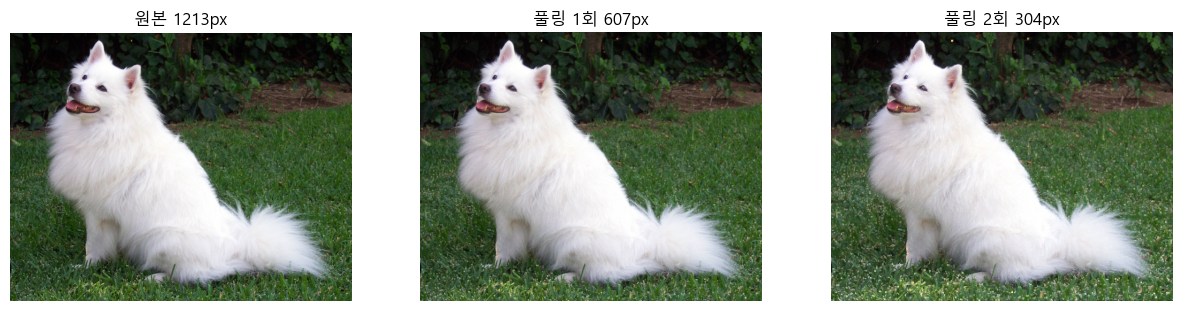

In [6]:
p1 = tf.nn.max_pool2d(img[np.newaxis].astype('float32'), ksize=2, strides=2, padding='SAME')
p2 = tf.nn.max_pool2d(p1, ksize=2, strides=2, padding='SAME')

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1); plt.imshow(img); plt.title(f'원본 {img.shape[0]}px'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(p1[0]); plt.title(f'풀링 1회 {p1.shape[1]}px'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(p2[0]); plt.title(f'풀링 2회 {p2.shape[1]}px'); plt.axis('off')
plt.show()

### 3. 손글씨 숫자 맞추기 

In [7]:
(x_tr, y_tr), (x_te, y_te) = tf.keras.datasets.mnist.load_data()

In [8]:
x_tr.shape

(60000, 28, 28)

In [9]:
y_tr.shape

(60000,)

In [10]:
# 6만장중 1만장만 사용 , (28,28) => (28,28,1) 흑백사진 : 채널 1
x_tr = x_tr[:10000, :, :, np.newaxis] / 255.0   
y_tr = y_tr[:10000]
x_te = x_te[:, :, :, np.newaxis] / 255.0

In [11]:
x_tr.shape

(10000, 28, 28, 1)

In [12]:
y_tr.shape

(10000,)

In [13]:
# 딥러닝 모델 만들기 위한 선형 모델 선언 => 층을 순서대로 쌓는 방식
# 입력 이미지  > Conv2D > MaxPooling2D > Conv2D > MaxPooling2D > Flatten > Dense > 최종 예측 ( Fully connected )  
# 컬러 이미지 = 채널 3 

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),

    # 이미지에서 특징을 찾는 층 => 2차원 이미지에서 특징을 찾는 층 
    # 필터 16개 사용 , 필터는 이미지에서 특징을 찾는 작은 도구 
    # 필터 1번 : 세로선 찾기 , 필터 2번 : 가로선 찾기 , 필터 3번 : 곡선 찾기...
    # 3 : 3*3크기의 필터를 사용 
    # activation = relu : 중요한 특징을 잘 살리고 , 불필요한 특징은 0으로 만드는 역할 
    tf.keras.layers.Conv2D(16, 3, activation='relu'),                          

    # 이미지 특징을 작게 요약하는 층 = 이미지 크기를 줄이면서 중요한 특징(가장 큰 값)만 추출하는 역할  
    # 1,3,5,7 pooling => 7 
    tf.keras.layers.MaxPooling2D(),                                            # 절반 요약

    # 앞에서 한번 특징을 찾았고 , 더 복잡한 특징을 찾음 , 필터 32개 사용
    # 섬세한 특징은 큰 윤곽을 잡고 찾는것이 통상 
    tf.keras.layers.Conv2D(32, 3, activation='relu'),                          # 필터 32개
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),                                                 # 펼치기

    # 모델이 숫자 이미지를 보고 , 최종적으로 0~9 중 하나를 판단하는 출력층 => 출력결과가 10개 
    tf.keras.layers.Dense(10, activation='softmax')                            # 0~9 판단
])

### 모델 학습을 위한 학습 방법을 설정 

In [17]:
"""
optimizer : 모델이 공부하는 방법 > 모델이 틀린답을 줄이도록 내부 값을 조정하는 하이퍼 파라미터 => 모델 학습 방법 
        - adam : 모델이 빠르고 , 안정적으로 학습하도록 도와주는 대표적인 방법 
        - sgd : 기본 , 느림 
loss : 모델이 얼마나 틀렸는지 계산하는 방법 > 모델의 오답 점수 
        - binary_crossentropy : 사용 상황이 둘중 하나를 분류할때 사용  
        - sparse_categorical_crossentropy : 여러개 중에 하나를 고르는 문제 > 다중분류 + 정수 라벨
        - categorical_crossentropy : 정답이 숫자 하나가 아니라 , 원-핫 인코딩 형태일때 사용 > 다중분류 + 원-핫 라벨  
        - [0,0,0,0,0,0,1,0,0] 표현될때 
        
metrics : 학습 결과를 어떤 기준으로 볼것인지의 기준 
        - accuracy 
        - mse ( 수치형 ) 
"""
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist = model.fit(x_tr, y_tr, epochs=3, batch_size=128, validation_split=0.1)
"""
epoch : 모델이 학습 데이터를 몇번 반복해서 학습하는지를 정하는 값 
epoch 이 너무 크면 Overfitting 위험성이 있음 
batch_size : 한번에 몇개의 데이터를 묶어서 학습할지를 정하는 값
    - 10000 / 128 = 약 78.1 : 전체 데이터를 한번 학습하는 동안 78번정도 나누어서 학습 

validation_split = 0.1 :
    실제 학습에 쓰이는 데이터는 90%라는 뜻 
"""
loss, acc = model.evaluate(x_te, y_te, verbose=0)
# verbose = 0 : 

print(f'테스트 정확도: {acc*100:.1f}%')

Epoch 1/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9746 - loss: 0.0924 - val_accuracy: 0.9730 - val_loss: 0.1066
Epoch 2/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9757 - loss: 0.0803 - val_accuracy: 0.9740 - val_loss: 0.1074
Epoch 3/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9780 - loss: 0.0729 - val_accuracy: 0.9660 - val_loss: 0.1131
테스트 정확도: 97.2%


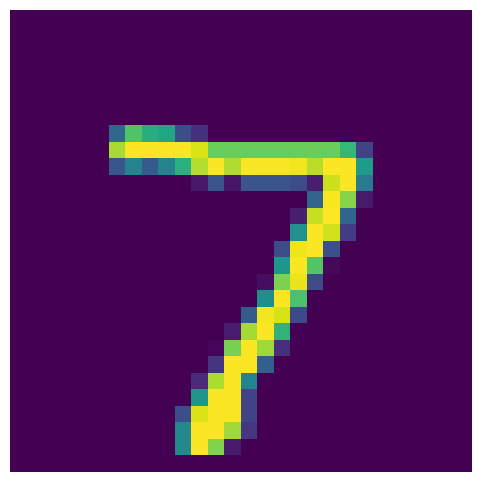

In [32]:
plt.figure(figsize=(10,6))
plt.imshow(x_te[0])
plt.axis('off')
plt.show()

In [35]:
# predict

pred = model.predict(x_te[:5],verbose=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


In [28]:
pred

array([[1.2055870e-10, 6.5847230e-11, 1.1659115e-06, 4.1130192e-05,
        1.5272268e-13, 2.4934931e-08, 4.0754906e-15, 9.9995041e-01,
        3.7795478e-09, 7.2674598e-06],
       [3.0119768e-06, 1.1835979e-05, 9.9996614e-01, 4.9445993e-07,
        1.4524745e-15, 2.6059712e-07, 1.7976545e-05, 5.5991592e-12,
        2.6010699e-07, 1.8618172e-13],
       [3.9073066e-06, 9.9838018e-01, 1.8652907e-04, 3.5964447e-05,
        5.9879810e-04, 8.1253802e-06, 8.1557722e-05, 6.7594473e-04,
        2.3090879e-05, 5.8789969e-06],
       [9.9723023e-01, 1.2440380e-11, 6.1205606e-04, 6.5706990e-06,
        2.4470546e-09, 4.5306497e-05, 5.1782385e-04, 1.2664427e-03,
        1.2961388e-07, 3.2145553e-04],
       [4.1116754e-09, 1.2146771e-08, 2.8088664e-08, 7.3970753e-08,
        9.9814546e-01, 8.7651255e-09, 3.5377465e-08, 2.2643974e-06,
        3.7681250e-08, 1.8520779e-03]], dtype=float32)

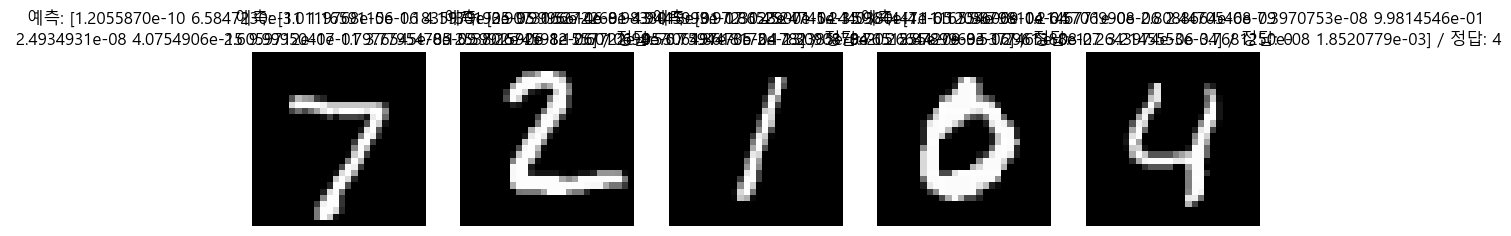

In [54]:
plt.figure(figsize=(13, 3))
plt.subplot(1,5,1)
plt.imshow(x_te[0,:,:,0], cmap='gray')
plt.title(f'예측: {pred[0]} / 정답: {y_te[0]}')
plt.axis('off')
plt.subplot(1,5,2)
plt.imshow(x_te[1,:,:,0], cmap='gray')
plt.title(f'예측: {pred[1]} / 정답: {y_te[1]}')
plt.axis('off')
plt.subplot(1,5,3) 
plt.imshow(x_te[2,:,:,0], cmap='gray'); 
plt.title(f'예측: {pred[2]} / 정답: {y_te[2]}')
plt.axis('off')
plt.subplot(1,5,4)
plt.imshow(x_te[3,:,:,0], cmap='gray')
plt.title(f'예측: {pred[3]} / 정답: {y_te[3]}')
plt.axis('off')
plt.subplot(1,5,5)
plt.imshow(x_te[4,:,:,0], cmap='gray')
plt.title(f'예측: {pred[4]} / 정답: {y_te[4]}')
plt.axis('off')
plt.show()